# Time Series Data Quality + Split Sanity Notebook

This notebook performs four tasks on a full dataset (`values` CSV + `date_time` CSV):

1. Detect likely interpolated values and replace them with `NaN`.
2. Check whether each series is sufficiently de-trended and optionally fix it.
3. Evaluate a proposed split scheme (`train_ratio`, `val_ratio`, `train_use_ratio`) for per-series risks.
4. Save edited output files with suffix `_edited`.

It also includes a plotting cell for one series with your requested split visualization:
- observations in **red**
- validation in **green**
- test in **blue**
- unused training head (due to `train_use_ratio`) shown with a much more transparent **red** line

In [147]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
from IPython.display import display


In [148]:
# -------- User inputs --------
VALUES_CSV = '/Users/davidwardan/Library/CloudStorage/OneDrive-Personal/Projects/cuTAGI_DW/data/hq/ts_weekly_values.csv'          # full values file
DATETIME_CSV = '/Users/davidwardan/Library/CloudStorage/OneDrive-Personal/Projects/cuTAGI_DW/data/hq/ts_weekly_datetimes.csv'      # full datetime file

# Interpolation detection settings
INTERP_TOL = 1e-10
INTERP_MIN_RUN_LEN = 2

# De-trend checks / fix settings
CHECK_DETREND = True
APPLY_DETREND_FIX = True
SLOPE_NORM_THRESHOLD = 0.2
R2_THRESHOLD = 0.15

# Split-scheme settings
INPUT_SEQ_LEN = 52
OUTPUT_SEQ_LEN = 1
CARRY_SPLIT_CONTEXT = True
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TRAIN_USE_RATIO = 1.0  # recommended sweep: {0.35, 0.50, 0.65, 0.80, 1.00}

# Output behavior
SAVE_EDITED_FILES = True
OUT_SUFFIX = '_edited'

In [149]:
# -------- Helpers --------
def load_values_dates(values_csv: str, datetime_csv: str):
    values_df = pd.read_csv(values_csv)
    dates_df = pd.read_csv(datetime_csv)

    if values_df.shape[1] != dates_df.shape[1] and dates_df.shape[1] != 1:
        raise ValueError(
            f'Incompatible shapes: values has {values_df.shape[1]} columns but date_time has {dates_df.shape[1]} columns.'
        )

    # Always keep datetime as text first; convert per-series only when needed.
    return values_df, dates_df


def trim_trailing_nans(x: np.ndarray):
    x = np.asarray(x, dtype=np.float64)
    if x.size == 0:
        return x
    valid = ~np.isnan(x)
    if not np.any(valid):
        return np.array([], dtype=np.float64)
    last = np.where(valid)[0][-1]
    return x[: last + 1]


def find_linear_interpolation_candidates(x: np.ndarray, tol: float = 1e-10, min_run_len: int = 2):
    """
    Flags interior points where x[i] is almost exactly linear between immediate neighbors.
    To reduce false positives, only keeps contiguous runs of length >= min_run_len.
    """
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    if n < 3:
        return np.zeros(n, dtype=bool)

    candidates = np.zeros(n, dtype=bool)
    for i in range(1, n - 1):
        if np.isnan(x[i - 1]) or np.isnan(x[i]) or np.isnan(x[i + 1]):
            continue
        midpoint = 0.5 * (x[i - 1] + x[i + 1])
        if np.isfinite(midpoint) and np.abs(x[i] - midpoint) <= tol:
            candidates[i] = True

    if min_run_len <= 1:
        return candidates

    filtered = np.zeros(n, dtype=bool)
    run_start = None
    for i in range(n):
        if candidates[i] and run_start is None:
            run_start = i
        elif (not candidates[i]) and run_start is not None:
            run_len = i - run_start
            if run_len >= min_run_len:
                filtered[run_start:i] = True
            run_start = None
    if run_start is not None:
        run_len = n - run_start
        if run_len >= min_run_len:
            filtered[run_start:n] = True

    return filtered


def detrend_stats(x: np.ndarray):
    """
    Returns slope, intercept, r2, slope_norm on non-NaN points.
    slope_norm = |slope| * (n-1) / std(y)
    """
    x = np.asarray(x, dtype=np.float64)
    idx = np.where(~np.isnan(x))[0]
    if len(idx) < 3:
        return {
            'has_enough_points': False,
            'slope': np.nan,
            'intercept': np.nan,
            'r2': np.nan,
            'slope_norm': np.nan,
        }

    t = idx.astype(np.float64)
    y = x[idx]
    slope, intercept = np.polyfit(t, y, 1)
    yhat = slope * t + intercept

    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 0.0 if ss_tot <= 0 else (1.0 - ss_res / ss_tot)

    y_std = np.std(y)
    slope_norm = np.inf if y_std == 0 else (np.abs(slope) * (len(y) - 1) / y_std)

    return {
        'has_enough_points': True,
        'slope': float(slope),
        'intercept': float(intercept),
        'r2': float(r2),
        'slope_norm': float(slope_norm),
    }


def maybe_fix_detrend(x: np.ndarray, slope_norm_threshold: float, r2_threshold: float, apply_fix: bool = True):
    stats = detrend_stats(x)
    if not stats['has_enough_points']:
        return x.copy(), False, stats

    needs_fix = (stats['slope_norm'] > slope_norm_threshold) and (stats['r2'] > r2_threshold)
    if (not needs_fix) or (not apply_fix):
        return x.copy(), needs_fix, stats

    out = x.astype(np.float64).copy()
    idx = np.where(~np.isnan(out))[0]
    trend = stats['slope'] * idx + stats['intercept']
    out[idx] = out[idx] - trend
    return out, needs_fix, stats


def split_single_series_like_pipeline(x: np.ndarray, train_ratio: float, val_ratio: float, train_use_ratio: float):
    """Mirrors experiments.utils._split_single_series behavior for diagnostics."""
    x_trim = trim_trailing_nans(x)
    n = len(x_trim)

    if n == 0:
        return {
            'n': 0,
            'n_train': 0,
            'n_val': 0,
            'n_test': 0,
            'n_train_used': 0,
            'train_end': 0,
            'val_end': 0,
        }

    if n == 1:
        n_train, n_val = 1, 0
    elif n == 2:
        n_train, n_val = 1, 0
    else:
        n_train = int(np.floor(n * train_ratio))
        n_val = int(np.floor(n * val_ratio))

        n_train = max(1, n_train)
        n_val = max(1, n_val)

        if n_train + n_val >= n:
            n_val = max(1, n - n_train - 1)
        if n_train + n_val >= n:
            n_train = max(1, n - n_val - 1)
        if n_train + n_val >= n:
            n_train, n_val = max(1, n - 2), 1

    n_test = max(0, n - n_train - n_val)
    train_end = n_train
    val_end = n_train + n_val

    n_train_used = int(np.floor(n_train * train_use_ratio))
    if n_train > 0:
        n_train_used = min(n_train, max(1, n_train_used))
    n_train_used_start = max(0, n_train - n_train_used)

    return {
        'n': n,
        'n_train': n_train,
        'n_val': n_val,
        'n_test': n_test,
        'n_train_used': n_train_used,
        'n_train_used_start': n_train_used_start,
        'train_end': train_end,
        'val_end': val_end,
    }


def split_windows_possible(length: int, input_seq_len: int, output_seq_len: int = 1):
    min_len = input_seq_len + output_seq_len
    return max(0, length - min_len + 1)


def add_suffix(path: str, suffix: str):
    p = Path(path)
    return str(p.with_name(f'{p.stem}{suffix}{p.suffix}'))

In [150]:
# -------- Run cleaning + detrend checks --------
values_df, dates_df = load_values_dates(VALUES_CSV, DATETIME_CSV)

edited_values_df = values_df.copy()
interp_report = []
detrend_report = []

for col_idx, col_name in enumerate(values_df.columns):
    x = pd.to_numeric(values_df.iloc[:, col_idx], errors='coerce').astype(float).values

    # 1) remove likely interpolated values
    interp_mask = find_linear_interpolation_candidates(
        x,
        tol=INTERP_TOL,
        min_run_len=INTERP_MIN_RUN_LEN,
    )
    x_clean = x.copy()
    x_clean[interp_mask] = np.nan

    interp_report.append({
        'series_idx': col_idx,
        'series_name': str(col_name),
        'n_points': int(len(x)),
        'n_interpolation_candidates': int(np.sum(interp_mask)),
    })

    # 2) de-trend check + optional fix
    if CHECK_DETREND:
        x_detrended, needs_fix, stats = maybe_fix_detrend(
            x_clean,
            slope_norm_threshold=SLOPE_NORM_THRESHOLD,
            r2_threshold=R2_THRESHOLD,
            apply_fix=APPLY_DETREND_FIX,
        )
    else:
        x_detrended, needs_fix = x_clean, False
        stats = {
            'has_enough_points': False,
            'slope': np.nan,
            'intercept': np.nan,
            'r2': np.nan,
            'slope_norm': np.nan,
        }

    edited_values_df.iloc[:, col_idx] = x_detrended

    detrend_report.append({
        'series_idx': col_idx,
        'series_name': str(col_name),
        'has_enough_points': bool(stats['has_enough_points']),
        'slope': float(stats['slope']) if np.isfinite(stats['slope']) else np.nan,
        'r2': float(stats['r2']) if np.isfinite(stats['r2']) else np.nan,
        'slope_norm': float(stats['slope_norm']) if np.isfinite(stats['slope_norm']) else np.nan,
        'needs_detrend_fix': bool(needs_fix),
    })

interp_report_df = pd.DataFrame(interp_report)
detrend_report_df = pd.DataFrame(detrend_report)

print('Done cleaning.')
print(f'Total likely interpolated points replaced by NaN: {int(interp_report_df.n_interpolation_candidates.sum())}')
if CHECK_DETREND:
    print(f"Series flagged as not well de-trended: {int(detrend_report_df['needs_detrend_fix'].sum())}")

display(interp_report_df.head(10))
display(detrend_report_df.head(10))

Done cleaning.
Total likely interpolated points replaced by NaN: 879
Series flagged as not well de-trended: 0


,series_idx,series_name,n_points,n_interpolation_candidates
0,0,DRU011PEAPRG854_cleaned,1582,0
1,1,DRU012PEAPRG854_cleaned,1582,0
2,2,DRU013PEAPRG883_cleaned,1582,0
3,3,DRU014PEAPRG883_cleaned,1582,0
4,4,GOU001ESAP-F020_cleaned,1582,119
5,5,LGA001EFAPRG910_cleaned,1582,0
6,6,LGA001PEAPRG910_cleaned,1582,0
7,7,LGA003EFAPRG910_cleaned,1582,30
8,8,LGA004EFAPRG920_cleaned,1582,45
9,9,LGA004ESAPRG829_cleaned,1582,27


,series_idx,series_name,has_enough_points,slope,r2,slope_norm,needs_detrend_fix
0,0,DRU011PEAPRG854_cleaned,True,-3.185869e-07,0.000002,0.004309,False
1,1,DRU012PEAPRG854_cleaned,True,-6.304197e-07,0.000004,0.006799,False
2,2,DRU013PEAPRG883_cleaned,True,-5.617570e-07,0.000010,0.010961,False
3,3,DRU014PEAPRG883_cleaned,True,-2.203846e-06,0.000227,0.052114,False
4,4,GOU001ESAP-F020_cleaned,True,7.606878e-07,0.000021,0.011022,False
5,5,LGA001EFAPRG910_cleaned,True,8.849225e-06,0.000018,0.013375,False
6,6,LGA001PEAPRG910_cleaned,True,9.435387e-06,0.001175,0.090049,False
7,7,LGA003EFAPRG910_cleaned,True,-3.464419e-05,0.002839,0.171531,False
8,8,LGA004EFAPRG920_cleaned,True,-5.684706e-06,0.000095,0.029254,False
9,9,LGA004ESAPRG829_cleaned,True,-2.368209e-06,0.000287,0.052038,False


In [151]:
# -------- Split-scheme diagnostics --------
if not (0.0 < TRAIN_RATIO < 1.0):
    raise ValueError('TRAIN_RATIO must be in (0, 1).')
if not (0.0 <= VAL_RATIO < 1.0):
    raise ValueError('VAL_RATIO must be in [0, 1).')
if TRAIN_RATIO + VAL_RATIO >= 1.0:
    raise ValueError('TRAIN_RATIO + VAL_RATIO must be < 1.')
if not (0.0 < TRAIN_USE_RATIO <= 1.0):
    raise ValueError('TRAIN_USE_RATIO must be in (0, 1].')

split_rows = []
for col_idx, col_name in enumerate(edited_values_df.columns):
    x = pd.to_numeric(edited_values_df.iloc[:, col_idx], errors='coerce').astype(float).values
    split = split_single_series_like_pipeline(
        x,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        train_use_ratio=TRAIN_USE_RATIO,
    )

    n = split['n']
    n_train = split['n_train']
    n_val = split['n_val']
    n_test = split['n_test']
    n_train_used = split['n_train_used']

    if CARRY_SPLIT_CONTEXT:
        val_effective = n_val + min(INPUT_SEQ_LEN, n_train)
        test_effective = n_test + min(INPUT_SEQ_LEN, n_train + n_val)
    else:
        val_effective = n_val
        test_effective = n_test

    train_windows = split_windows_possible(n_train_used, INPUT_SEQ_LEN, OUTPUT_SEQ_LEN)
    val_windows = split_windows_possible(val_effective, INPUT_SEQ_LEN, OUTPUT_SEQ_LEN)
    test_windows = split_windows_possible(test_effective, INPUT_SEQ_LEN, OUTPUT_SEQ_LEN)

    split_rows.append({
        'series_idx': col_idx,
        'series_name': str(col_name),
        'n_total_trimmed': n,
        'n_train_full': n_train,
        'n_train_used': n_train_used,
        'n_train_unused': max(0, n_train - n_train_used),
        'n_val_core': n_val,
        'n_test_core': n_test,
        'train_windows': train_windows,
        'val_windows': val_windows,
        'test_windows': test_windows,
        'problem_empty_series': n == 0,
        'problem_train_no_windows': train_windows == 0,
        'problem_val_empty_core': n_val == 0,
        'problem_test_empty_core': n_test == 0,
        'problem_val_no_windows': val_windows == 0,
        'problem_test_no_windows': test_windows == 0,
        'problem_any': (
            (n == 0)
            or (train_windows == 0)
            or (n_val == 0)
            or (n_test == 0)
            or (val_windows == 0)
            or (test_windows == 0)
        ),
    })

split_check_df = pd.DataFrame(split_rows)

problem_cols = [
    'problem_empty_series',
    'problem_train_no_windows',
    'problem_val_empty_core',
    'problem_test_empty_core',
    'problem_val_no_windows',
    'problem_test_no_windows',
]
summary = split_check_df[problem_cols].sum().rename('n_series').to_frame()

print('Split diagnostic summary:')
display(summary)
print('Problematic series (first 30):')
display(split_check_df[split_check_df.problem_any].head(30))

Split diagnostic summary:


,n_series
problem_empty_series,0
problem_train_no_windows,0
problem_val_empty_core,0
problem_test_empty_core,0
problem_val_no_windows,0
problem_test_no_windows,0


Problematic series (first 30):


,series_idx,series_name,n_total_trimmed,n_train_full,n_train_used,n_train_unused,n_val_core,n_test_core,train_windows,val_windows,test_windows,problem_empty_series,problem_train_no_windows,problem_val_empty_core,problem_test_empty_core,problem_val_no_windows,problem_test_no_windows,problem_any


In [152]:
# -------- Save edited files --------
values_out = add_suffix(VALUES_CSV, OUT_SUFFIX)
dates_out = add_suffix(DATETIME_CSV, OUT_SUFFIX)

if SAVE_EDITED_FILES:
    edited_values_df.to_csv(values_out, index=False)
    dates_df.to_csv(dates_out, index=False)
    print(f'Saved edited values:   {values_out}')
    print(f'Saved edited datetime: {dates_out}')
else:
    print('SAVE_EDITED_FILES=False, no files written.')

Saved edited values:   /Users/davidwardan/Library/CloudStorage/OneDrive-Personal/Projects/cuTAGI_DW/data/hq/ts_weekly_values_edited.csv
Saved edited datetime: /Users/davidwardan/Library/CloudStorage/OneDrive-Personal/Projects/cuTAGI_DW/data/hq/ts_weekly_datetimes_edited.csv


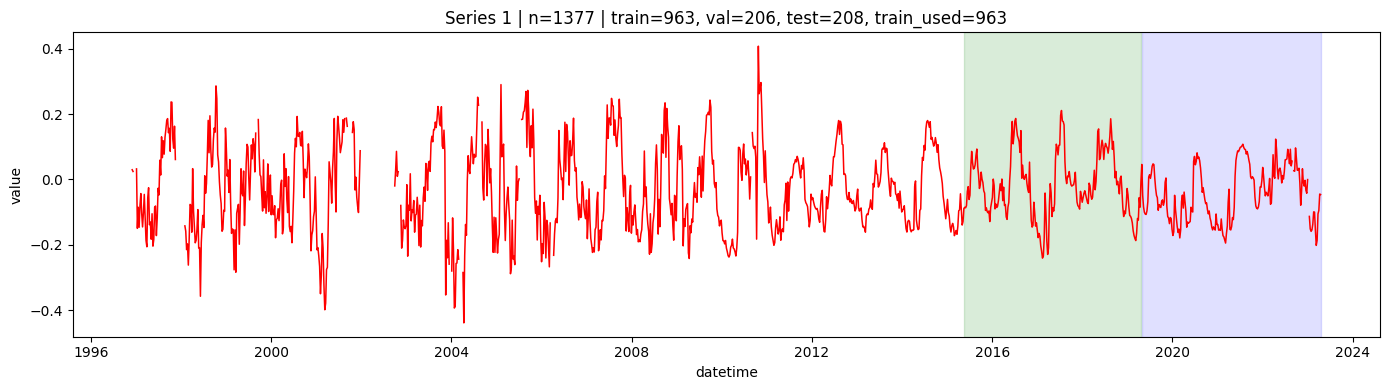

In [153]:
# -------- Plot one series with split shading --------
PLOT_SERIES_IDX = 1
PLOT_FIGSIZE = (14, 4)


def series_datetime(dates_df: pd.DataFrame, series_idx: int):
    if dates_df.shape[1] == 1:
        raw = dates_df.iloc[:, 0]
    else:
        raw = dates_df.iloc[:, series_idx]
    dt = pd.to_datetime(raw, errors='coerce')
    return dt


def plot_series_with_split(
    values_df: pd.DataFrame,
    dates_df: pd.DataFrame,
    series_idx: int,
    train_ratio: float,
    val_ratio: float,
    train_use_ratio: float,
    figsize=(14, 4),
):
    x_raw = pd.to_numeric(values_df.iloc[:, series_idx], errors='coerce').astype(float).values
    dt_raw = series_datetime(dates_df, series_idx)

    x_trim = trim_trailing_nans(x_raw)
    n = len(x_trim)
    if n == 0:
        raise ValueError(f'Series {series_idx} is empty after trimming trailing NaNs.')

    dt_trim = dt_raw.iloc[:n]
    use_datetime_axis = bool(dt_trim.notna().all())
    x_axis = dt_trim if use_datetime_axis else np.arange(n)

    split = split_single_series_like_pipeline(x_trim, train_ratio, val_ratio, train_use_ratio)

    train_end = split['train_end']
    val_end = split['val_end']
    train_used_start = split['n_train_used_start']

    fig, ax = plt.subplots(figsize=figsize)

    # Green: validation core
    if train_end < val_end:
        ax.axvspan(x_axis[train_end], x_axis[val_end - 1], color='green', alpha=0.15)

    # Blue: test core
    if val_end < n:
        ax.axvspan(x_axis[val_end], x_axis[n - 1], color='blue', alpha=0.12)

    # Main observation in red, no legend. The dropped training head is drawn
    # with a lower alpha instead of adding extra region shading.
    if train_used_start > 0:
        ax.plot(x_axis[:train_used_start], x_trim[:train_used_start], color='red', linewidth=1.1, alpha=0.18)
    ax.plot(x_axis[train_used_start:], x_trim[train_used_start:], color='red', linewidth=1.1, alpha=1.0)

    ax.set_title(f'Series {series_idx} | n={n} | train={split["n_train"]}, val={split["n_val"]}, test={split["n_test"]}, train_used={split["n_train_used"]}')
    ax.set_xlabel('datetime' if use_datetime_axis else 'index')
    ax.set_ylabel('value')
    plt.tight_layout()
    plt.show()


plot_series_with_split(
    values_df=edited_values_df,
    dates_df=dates_df,
    series_idx=PLOT_SERIES_IDX,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    train_use_ratio=TRAIN_USE_RATIO,
    figsize=PLOT_FIGSIZE,
)
